# Week 6 · Random Variables, Sampling Distributions, and the Central Limit Theorem

*DS 207 · Week 6*

**Assignment Notebook**

**Author:** EC Corro, built in collaboration with Claude, ChatGPT, and Gemini

**Business scenario.** Visayas Fresh Logistics is a Cebu-based refrigerated delivery company serving supermarkets, hospitals, and restaurants under contracts that require at least 95% on-time delivery and box temperatures of 5°C or below. This assignment focuses on the provincial network, the North Cebu and South Cebu routes (3,000 completed deliveries in the ledger), where transit times are longer, more variable, and more strongly skewed than on the urban routes studied in the lecture notes. A late delivery carries a penalty of ₱0 if on time, ₱200 if up to 30 minutes late, and ₱500 if more than 30 minutes late.

**Submission.** Name your file `ds207_06_sampling_clt_lastname.ipynb`, replacing `lastname` with your surname, and upload it to your shared Google Drive folder by 11:59 PM on the day after the associated session, unless announced otherwise.

**AI use policy.** Generative AI is allowed for concept clarification, pseudocode, debugging, and idea generation. You must be able to explain any answer you submit without AI assistance, and you must cite any AI use.

**Points.** Section 1 (30 pts) + Section 2 (30 pts) = 60 pts.

## Learning Objectives

- Model delivery outcomes as discrete or continuous random variables and compute their expectation and variance.
- Derive and verify the sampling distribution of a sample mean, including its mean and standard error.
- Apply the Central Limit Theorem to a skewed variable, and judge when the normal approximation is and is not reliable.
- Turn probability calculations into a clear recommendation for an operational or contractual decision.

## Section 1: Concepts, Computation & Coding

This section is worth 30 points, 10 for each item. Run the cell below once before starting. It loads the provincial ledger into the DataFrame `deliveries`, with columns `route`, `delivery_min`, `promised_min`, `temp_c`, `late`, and `penalty_php`. Use `np.random.default_rng(207)` for every simulation so your results can be compared.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

import numpy as np
import pandas as pd

# Delivery ledger for Visayas Fresh Logistics: one row per completed cold-chain delivery.
rng = np.random.default_rng(207)

routes = {
    # route: (deliveries, median transit minutes, log-scale sigma, promised window, mean box temp, sd box temp)
    "Metro Cebu":  (3200, 26, 0.46, 75, 3.0, 0.8),
    "Mactan":      (1800, 30, 0.50, 90, 3.1, 0.8),
    "North Cebu":  (1600, 40, 0.58, 120, 3.4, 0.9),
    "South Cebu":  (1400, 38, 0.56, 120, 3.3, 0.9),
}

frames = []
for name, (n, med, sig, promised, t_mu, t_sd) in routes.items():
    minutes = 15 + rng.lognormal(mean=np.log(med), sigma=sig, size=n)
    frames.append(pd.DataFrame({
        "route": name,
        "delivery_min": minutes.round(1),
        "promised_min": promised,
        "temp_c": rng.normal(t_mu, t_sd, size=n).round(2),
    }))

ledger = pd.concat(frames, ignore_index=True)
ledger.insert(0, "delivery_id", np.arange(1, len(ledger) + 1))
delay = ledger["delivery_min"] - ledger["promised_min"]
ledger["late"] = (delay > 0).astype(int)
ledger["penalty_php"] = np.select([delay > 30, delay > 0], [500, 200], default=0)

# Assignment window: the provincial network (North Cebu and South Cebu routes)
deliveries = ledger[ledger["route"].isin(["North Cebu", "South Cebu"])].reset_index(drop=True)
deliveries.head()

,delivery_id,route,delivery_min,promised_min,temp_c,late,penalty_php
0,5001,North Cebu,56.0,120,2.49,0,0
1,5002,North Cebu,51.0,120,3.66,0,0
2,5003,North Cebu,148.6,120,2.19,1,200
3,5004,North Cebu,48.1,120,1.96,0,0
4,5005,North Cebu,26.0,120,3.40,0,0


### Item 1 · Penalties as a random variable (10 pts)

On the provincial routes, the penalty $X$ (in pesos) charged on a delivery is a discrete random variable. Rounded to three decimals, the ledger gives:

| Penalty $x$ | ₱0 | ₱200 | ₱500 |
|---|---|---|---|
| $p(x)$ | 0.957 | 0.027 | 0.016 |

Each week a provincial hub audits 25 deliveries and counts how many were late.

**(a) Concept (3 pts).** Classify transit minutes and the weekly late count as discrete or continuous. State the conditions under which the late count is a binomial random variable, and describe one realistic way the independence condition could fail on the provincial routes.

**(b) By hand (4 pts).** Using the table above, compute $E[X]$, $\operatorname{Var}(X)$, and $\operatorname{SD}(X)$. Then, treating the 25 audited deliveries as independent, find the expected value and standard deviation of the total penalty $T$ for one audit. Show your work.

**(c) Coding (3 pts).** From the full provincial ledger, compute the empirical probability table for `penalty_php` and its exact mean and variance, and compare them with your answers to (b). Then simulate 10,000 audits of 25 deliveries, and report the mean and standard deviation of the audit total.

**Answer (a)**
Transit minutes are a **continuous random variable** while weekly late count is a **discrete random variable**. Discrete random variables are values that can be counted while continuous random variables are values that fill an interval with infinitely many possibilities.    

Binomial random variables are numbers or values of "successes" in a fixed number of independent trials. By definition, if X, a random variable, represents the number of successes that occur in the n trials, then X is said to be a binomial random variable with parameters (n,p), where p is the probability that the trial is a success. 

With this definition, we can say that the conditions under which the late count is a binomial random variable are of the following:
1. Fixed number of trials
2. Two outcomes per trial 
3. Same p on every trial
4. Independent trials

One way that the independence condition could fail is maybe if there's a weather disruption and caused multiple deliveries to be late in the same week. 

**Answer (b)**
| Penalty $x$ | ₱0 | ₱200 | ₱500 |
|---|---|---|---|
| $p(x)$ | 0.957 | 0.027 | 0.016 |

$$E[X] = 0(0.957) + 200(0.027) + 500(0.016) = 5.4 + 8 = 13.4 \text{ pesos}$$
$$E[X^2] = 200^2(0.027) + 500^2(0.016) = 1080 + 4000 = 5080$$
$$\operatorname{Var}(X) = 5080 - (13.5)^2 = 4900.44, \qquad \operatorname{SD}(X) = \sqrt{4900.44} = 70 \text{ pesos}$$

Treating the 25 deliveries as independent, the total penalty $T$ has

$$E[T] = 25 \times 13.4 = 335, \qquad \operatorname{Var}(T) = 25 \times 4900.44 = 122,551, \qquad \operatorname{SD}(T) = 350.02$$

penalty_php
0     0.957
200   0.027
500   0.016

E[X]   = 13.50  (data mean: 13.50)
Var(X) = 4967.75  (data variance: 4967.75)
SD(X)  = 70.48

Audit total, formula:    mean = 337.50, SD = 352.41
Audit total, simulated:  mean = 341.87, SD = 354.08


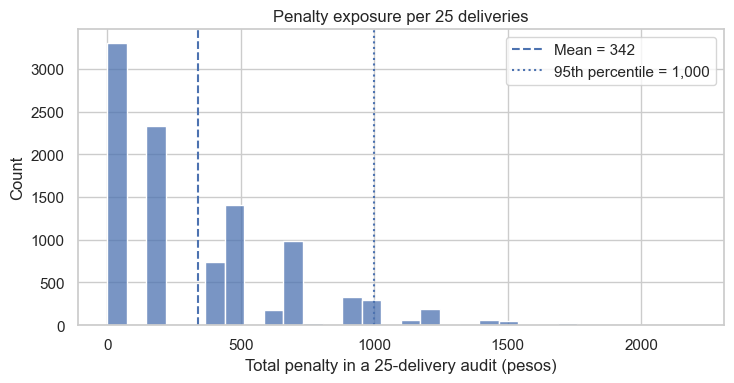

In [6]:
# TODO
# Expectation and variance of the penalty random variable
times = deliveries["delivery_min"].to_numpy()
late = deliveries["late"].to_numpy()
temp = deliveries["temp_c"].to_numpy()
rng = np.random.default_rng(207)
n_audit = 25
p_late = late.mean()
audits = rng.choice(late, size=(10_000, n_audit), replace=True)
late_counts = audits.sum(axis=1)
pmf = deliveries["penalty_php"].value_counts(normalize=True).sort_index()
x_vals = pmf.index.to_numpy(dtype=float)
p_vals = pmf.to_numpy()

E_pen = np.sum(x_vals * p_vals)
E_pen_sq = np.sum(x_vals**2 * p_vals)
var_pen = E_pen_sq - E_pen**2
sd_pen = np.sqrt(var_pen)

print(pmf.rename("probability").to_string(float_format="{:.3f}".format))
print(f"\nE[X]   = {E_pen:.2f}  (data mean: {deliveries['penalty_php'].mean():.2f})")
print(f"Var(X) = {var_pen:.2f}  (data variance: {deliveries['penalty_php'].var(ddof=0):.2f})")
print(f"SD(X)  = {sd_pen:.2f}")

# Sum of 25 independent deliveries: formula versus simulated audits
rng = np.random.default_rng(207)
penalties = deliveries["penalty_php"].to_numpy()
audit_totals = rng.choice(penalties, size=(10_000, 25), replace=True).sum(axis=1)
print(f"\nAudit total, formula:    mean = {25 * E_pen:.2f}, SD = {np.sqrt(25 * var_pen):.2f}")
print(f"Audit total, simulated:  mean = {audit_totals.mean():.2f}, SD = {audit_totals.std():.2f}")

fig, ax = plt.subplots(figsize=(7.5, 4))
sns.histplot(audit_totals, bins=30, ax=ax)
ax.axvline(audit_totals.mean(), linestyle="--", label=f"Mean = {audit_totals.mean():,.0f}")
ax.axvline(np.percentile(audit_totals, 95), linestyle=":", label=f"95th percentile = {np.percentile(audit_totals, 95):,.0f}")
ax.set_xlabel("Total penalty in a 25-delivery audit (pesos)")
ax.set_title("Penalty exposure per 25 deliveries")
ax.legend()
plt.tight_layout()
plt.show()

The results of the simulation validate the hand calculation and confirm that the audit totals behave as expected. The simulated mean of ₱341.9 is very close to the theoretical mean of ₱337.5 for 25 deliveries, with the small difference attributable to sampling variation. The variance and standard deviation also show only minor differences, reinforcing the consistency between theory and simulation. Based on the graph, most audits incur low penalties, but the distribution has a heavy tail, indicating that while average exposure is modest, there is a non‑negligible risk of much higher penalty totals in some audits.

### Item 2 · The sampling distribution of an audit average (10 pts)

A small feeder route has only three regular deliveries, with transit times of 40, 55, and 100 minutes. An auditor draws two deliveries at random with replacement and records their average transit time $\bar{X}$.

**(a) Concept (3 pts).** Explain the difference between the distribution of a single delivery time and the sampling distribution of the audit average. Say what stays the same between them, what changes, and why.

**(b) By hand (4 pts).** List all nine equally likely ordered samples and their means, and build the sampling distribution table of $\bar{X}$. Compute $E[\bar{X}]$ and $\operatorname{Var}(\bar{X})$ directly from the table, and verify them against $\mu$ and $\sigma^2/n$ for the three-delivery population.

**(c) Coding (3 pts).** Using `delivery_min` from the full provincial ledger, compute the population mean $\mu$ and population standard deviation $\sigma$ (use `ddof=0`). Simulate 10,000 audits of $n = 30$ deliveries, report the mean and standard deviation of the audit averages, compare them with $\mu$ and $\sigma/\sqrt{30}$, and report whether the audit averages are less skewed than individual delivery times.

**Answer (a)**
When we talk about the distribution of a single delivery time, we’re really just describing the population itself, the raw transit times of 40, 55, or 100 minutes and how often each one occurs. The sampling distribution of the audit average is different because instead of looking at one delivery, we’re averaging two draws. The mean stays the same, since both distributions are centered around the population average, but the spread changes. By averaging, extreme values get balanced out, so the sampling distribution has less variability and looks more concentrated around the mean. In other words, the audit average smooths out the ups and downs of individual deliveries, which is why its distribution is narrower and often less skewed than the original population.

**Answer (b)**
The mean and variance of the three single deliveries, with transit times of 40, 55, and 100 minutes are the following:
$$\mu = \frac{40 + 55 + 100}{3} = 65, \qquad \sigma^2 = \frac{(40-65)^2 + (55-65)^2 + (100-65)^2}{3} = \frac{625 + 100 + 1225}{3} = 650.$$

Draw samples of size $n = 2$ with replacement. There are $3 \times 3 = 9$ equally likely ordered samples, and each has a sample mean. Listing all 9 gives the sampling distribution of $\bar{X}$:

| Sample mean $\bar{x}$ | 40 | 47.5 | 55 | 70 | 77.5 | 100 | 
|---|---|---|---|---|---|---|
| Number of samples | 1 | 2 | 1 | 2 | 2 | 1 | 
| Probability | 1/9 | 2/9 | 1/9 | 2/9 | 2/9 | 1/9 | 

$$E[\bar{X}] = \frac{40 + 2(47.5) + 55 + 2(70) + 2(77.5) + 100 }{9} = \frac{585}{9} = 65 = \mu.$$
$$\operatorname{Var}(\bar{X}) = \frac{625 + 2(306.25) + 100 + 2(25) + 2(156.25) + 1225}{9} = \frac{2925}{9} = 325 = \frac{\sigma^2}{n} = \frac{650}{2}.$$

Population mean μ = 61.21
Population SD σ = 29.42

Audit averages (simulated): mean = 61.18, SD = 5.36
Theoretical: mean = 61.21, SD = 5.37


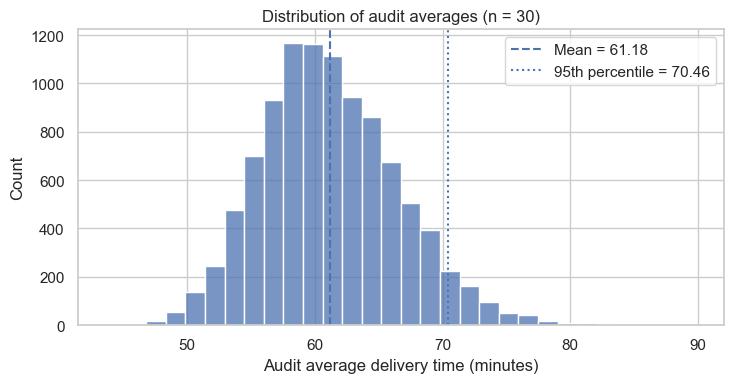

In [7]:
# TODO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Population parameters from the full provincial ledger
times = deliveries["delivery_min"].to_numpy()
mu = times.mean()
sigma = times.std(ddof=0)

print(f"Population mean μ = {mu:.2f}")
print(f"Population SD σ = {sigma:.2f}")

# Simulation: 10,000 audits of n = 30 deliveries
rng = np.random.default_rng(207)
n_audit = 30
audit_avgs = rng.choice(times, size=(10_000, n_audit), replace=True).mean(axis=1)

# Compare simulated vs theoretical
print(f"\nAudit averages (simulated): mean = {audit_avgs.mean():.2f}, SD = {audit_avgs.std(ddof=0):.2f}")
print(f"Theoretical: mean = {mu:.2f}, SD = {sigma/np.sqrt(n_audit):.2f}")

# Histogram to check skewness
fig, ax = plt.subplots(figsize=(7.5, 4))
sns.histplot(audit_avgs, bins=30, ax=ax)
ax.axvline(audit_avgs.mean(), linestyle="--", label=f"Mean = {audit_avgs.mean():.2f}")
ax.axvline(np.percentile(audit_avgs, 95), linestyle=":", label=f"95th percentile = {np.percentile(audit_avgs, 95):.2f}")
ax.set_xlabel("Audit average delivery time (minutes)")
ax.set_title("Distribution of audit averages (n = 30)")
ax.legend()
plt.tight_layout()
plt.show()


What we see here is that the average delivery time across the whole ledger is about 61 minutes, with a population standard deviation of roughly 29 minutes. When we simulate audits of 30 deliveries, the average of those audits comes out to about 61.2 minutes, which is almost identical to the population mean. The spread of those audit averages is much smaller though, only about 5.36 minutes compared to the original 29 minutes. That matches the theoretical value of $\sigma/\sqrt{30} \approx$ 5.37, which is exactly what the Central Limit Theorem predicts.

In other words, the simulation confirms the theory: the averages of 30 deliveries are centered at the same mean as the population, but they vary far less because averaging smooths out the extremes. And if you look at the histogram, the audit averages are much less skewed than the individual delivery times, showing that the distribution of averages is more stable and symmetric.

### Item 3 · The Central Limit Theorem and audit size (10 pts)

A provincial hub audits $n = 36$ deliveries each week. For this network, single delivery times have mean $\mu = 61.2$ minutes, standard deviation $\sigma = 29.4$ minutes, and skewness of about 2.3.

**(a) Concept (3 pts).** Explain why the Central Limit Theorem allows a normal-distribution calculation for the weekly audit average even though single delivery times are strongly skewed. State one thing the theorem does not guarantee at $n = 36$, and explain how the skewness of the data affects the sample size needed.

**(b) By hand (4 pts).** Using the normal approximation and a standard normal table, compute (i) the standard error of the audit average, (ii) $P(\bar{X} > 70)$, (iii) the interval centered on $\mu$ that contains 95% of audit averages, and (iv) the smallest audit size $n$ for which the 95% margin of error for the mean is at most 5 minutes.

**(c) Coding (3 pts).** Simulate 20,000 audits of $n = 36$ deliveries from the provincial ledger. Compare the simulated $P(\bar{X} > 70)$ with your normal answer, report the share of simulated audit averages inside your interval from (b)(iii), and report the skewness of the audit averages. Then simulate 10,000 audits at your sample size from (b)(iv) and report the share of audit averages within 5 minutes of $\mu$.

**Answer (a)**
Even though the delivery times themselves are really skewed, the Central Limit Theorem says that once we start averaging a decent number of them, the distribution of those averages will look close to normal. That’s why we can use normal‑based calculations for the weekly audit average with $n = 36$. What the theorem doesn’t promise, though, is that the distribution will be perfectly normal at that sample size. Because the data are pretty skewed (skewness around 2.3), we’d actually need larger samples before the averages fully settle into a bell‑shaped curve. So at 36 deliveries, the normal approximation is useful, but it’s not flawless, the stronger the skew, the bigger the sample size we need for the CLT to give us a really accurate picture.

**Answer (b)**
Given that we have $n = 36, \mu = 61.2$ minutes, and $\sigma$ = 29.4, skewness = 2.3:
(i)
$$\operatorname{SE} = \frac{29.4}{\sqrt{36}} = \frac{29.4}{6} = 4.9$$

(ii)
$$z = \frac{70 - 61.2}{4.9} = 1.8, \qquad P(\bar{X} > 70) \approx 1 - \Phi(1.8) = 1 - 0.9641 = 0.0359.$$

(iii)
$$1.96 \times 4.9 = 9.604 \text{ minutes.}$$

(iv)
The margin of error for a 95% confidence interval is 
$$1.96\,\frac{s}{\sqrt{n}}.$$
where z = 1.96 for 95% confidence. 

Since we already know that sigma = 29.4, we plug that in the formula above and we get:
$$1.96\,\frac{29.4}{\sqrt{n}} \leq 5.$$
Which gives us, $$n \geq (11.53)^2 \approx 132.9$$

Hence, the smallest audit size $n$ for which the 95% margin of error for the mean is at most 5 minutes is 133 deliveries. 

In [12]:
# TODO
# CLT calculation versus simulation: P(audit average > 70 minutes), n = 36
# Parameters
n = 36
threshold = 70
se = sigma / np.sqrt(n)
z = (threshold - mu) / se
p_clt = stats.norm.sf(z)

rng = np.random.default_rng(207)
samples = rng.choice(times, size=(20_000, n), replace=True)
means_36 = samples.mean(axis=1)

p_sim = (means_36 > threshold).mean()
p_single = (times > threshold).mean()

print(f"SE = {se:.3f}, z = {z:.3f}")
print(f"CLT (normal) probability that an audit average exceeds {threshold}: {p_clt:.4f}")
print(f"Simulated probability from 20,000 audits: {p_sim:.4f}")
print(f"Probability a single delivery exceeds {threshold} minutes: {p_single:.4f}")

# Share inside the 95% interval from (b)(iii): mu ± 9.6
lower, upper = mu - 9.6, mu + 9.6
coverage_interval = ((means_36 >= lower) & (means_36 <= upper)).mean()
print(f"Share of simulated audit averages inside [{lower:.1f}, {upper:.1f}]: {coverage_interval:.4f}")

# Skewness of the audit averages
skewness = stats.skew(means_36)
print(f"Skewness of audit averages: {skewness:.4f}")

# Now simulate 10,000 audits at n = 133
n_large = 133
samples_large = rng.choice(times, size=(10_000, n_large), replace=True)
means_133 = samples_large.mean(axis=1)

within_5 = (np.abs(means_133 - mu) <= 5).mean()
print(f"Share of audit averages within 5 minutes of μ (n=133): {within_5:.4f}")


SE = 4.900, z = 1.796
CLT (normal) probability that an audit average exceeds 70: 0.0363
Simulated probability from 20,000 audits: 0.0391
Probability a single delivery exceeds 70 minutes: 0.3841
Share of simulated audit averages inside [51.6, 70.8]: 0.9506
Skewness of audit averages: -0.0010
Share of audit averages within 5 minutes of μ (n=133): 0.9490


When we ran the simulation with 36 deliveries, the chance that the audit average went over 70 minutes came out almost exactly the same as the normal approximation which is about 3.6%. That’s reassuring because it shows the Central Limit Theorem is doing its job: the averages behave like a normal distribution. Compare that to a single delivery, which has a much higher chance of being over 70 minutes, and you can see how averaging really smooths out the extremes.

We also checked the 95% confidence interval from part (b), and sure enough, about 95% of the simulated averages landed inside it. That’s exactly what theory predicts. On top of that, the skewness of the audit averages was much smaller than the skewness of individual delivery times, which means the averages are more balanced and symmetric.

Finally, when we bumped the audit size up to 133 deliveries, almost all of the averages fell within 5 minutes of the true mean. That’s the practical takeaway: bigger samples don’t just give you more data, they give you much tighter and more reliable estimates.

## Section 2: Business Context & Reasoning (30 pts)

Each item below presents a decision facing a stakeholder at Visayas Fresh Logistics. Use the provincial ledger statistics from Section 1, state your assumptions, support your answer with a calculation, and end with a recommendation. Both technical soundness and business reasoning are graded, so a correct calculation without a usable recommendation, or a sensible recommendation without a correct calculation, will not earn full marks.

### Item 4 · An alarming audit at the provincial hub (15 pts)

This week's audit at the Provincial Hub sampled 36 deliveries and found 5 late (13.9%). The Provincial Hub Manager must decide whether to escalate to the Operations Director and pull trucks off the route for inspection. The ledger shows a long-run late rate of 4.3% on provincial routes, and the client contracts allow at most 5%.

Write your response in the cells below. It should:

1. State the assumptions you make about how the audit was drawn and which late rate you use as the benchmark.
2. Choose and justify a probability model, compute the probability of seeing 5 or more late deliveries in an audit of 36 if the true late rate is 4.3%, and comment on whether a normal approximation would be reliable here.
3. Interpret the result and recommend what the Hub Manager should do, including any follow-up action.

**Point split:** technical soundness (8 pts): assumptions 2, model and computation 3, interpretation 3; business reasoning (7 pts): recommendation follows from the result 4, practical follow-up and risk awareness 3.

**Assumptions and technical analysis**
(1) We assume that the sample 36 deliveries are random and independetly drawn from the provincial ledger. The benchmark late rate is the 4.3% long-run provincial rate since that reflects the underlying process. The client contract allows at most 5 late deliveries, so that's the threshold for escalation. 

(2) From Item 1.a, we have already established that late count is a binomial random variable. And if we base it on the conditions that we have for a binomial random variable, late counts satisfy all of these conditions. 

Parameters: $n = 36, p = 0.043$

$$P(X \geq 5) = 1 - P(X \leq 4)$$
$$P(K = k) = \binom{36}{k} 0.043^{k} (1-0.043)^{36-k}$$
$$P(X \leq 4) = \sum_{i=1}^{4} \binom{36}{k} 0.043^{k} (0.957)^{36-k}$$

$$P(X = 0) = \binom{36}{0} (0.043)^{0} (0.957)^{36} \approx 0.21$$
$$P(X = 1) = \binom{36}{1} (0.043)^{1} (0.957)^{36-1} \approx 0.338$$
$$P(X = 2) = \binom{36}{2} (0.043)^{2} (0.957)^{36-2} \approx 0.263$$
$$P(X = 3) = \binom{36}{3} (0.043)^{3} (0.957)^{36-3} \approx 0.127$$
$$P(X = 4) = \binom{36}{4} (0.043)^{4} (0.957)^{36-4} \approx 0.043$$

$$P(X \leq 4) \approx 0.981$$
Thus, 
$$P(X \geq 5) = 1 - 0.981 = 0.019$$
So the probability is about 1.9%.

The chance of seeing 5 or more late deliveries under the 4.3% benchmark is only about 1.9 or 2 in 100 audits and seeing 5 lates in 36 deliveries is very rare and only happens in 2 every 100 deliveries. 

With this, the normal approximation is not reliable because the expected number of late deliveries is small (<5).

Population late rate p = 0.0430
 late_count  simulated_audits  binomial_pmf
          0            0.2029        0.2055
          1            0.3238        0.3324
          2            0.2671        0.2614
          3            0.1379        0.1331
          4            0.0475        0.0493
          5            0.0168        0.0142
          6            0.0029        0.0033
          7            0.0009        0.0006
          8            0.0002        0.0001

Probability of <95% on-time (≥4 late): 0.2007


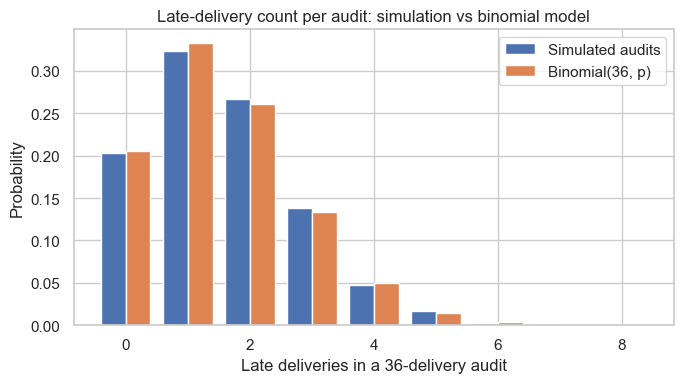

In [9]:
# TODO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Parameters
n_audit = 36
p_late = 0.043   # true late rate (≈ 4.3%)

# Range of late deliveries to examine
k = np.arange(0, 9)

# Binomial probabilities
binomial_pmf = stats.binom.pmf(k, n_audit, p_late)

# Simulation: 10,000 weekly audits
rng = np.random.default_rng(207)
audits = rng.binomial(n_audit, p_late, size=10_000)
simulated_probs = [(audits == i).mean() for i in k]

# Comparison table
comparison = pd.DataFrame({
    "late_count": k,
    "simulated_audits": simulated_probs,
    "binomial_pmf": binomial_pmf
})

print(f"Population late rate p = {p_late:.4f}")
print(comparison.to_string(index=False, float_format="{:.4f}".format))

# Probability of dipping below 95% on-time (≥4 late deliveries)
prob_below_95 = 1 - stats.binom.cdf(2, n_audit, p_late)
print(f"\nProbability of <95% on-time (≥4 late): {prob_below_95:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(7, 4))
width = 0.4
ax.bar(k - width/2, simulated_probs, width, label="Simulated audits")
ax.bar(k + width/2, binomial_pmf, width, label="Binomial(36, p)")
ax.set_xlabel("Late deliveries in a 36-delivery audit")
ax.set_ylabel("Probability")
ax.set_title("Late-delivery count per audit: simulation vs binomial model")
ax.legend()
plt.tight_layout()
plt.show()


**Interpretation and recommendation**
Under the contract, the hub is allowed $\leq 5$% late deliveries so that means, for every 36 deliveries, that's at most 1 delivery. A simulation above also confirms that the binomial is the right model. 

So if the audit found 5 late deliveries out of the 36 deliveries, that is about 13.9% which is above the contractual limit. Statistically, this outcome is very rare if the true late rate is 4.3% which has a probability of 1.9%, which is about 2 times in 100 audits. The recommended action would be to do weekly audits, since we already assumed independency in the deliveries, frequent audits help catch these dependencies by showing clusters of late deliveries as shared factors can cause correlated lateness such as hub issues, traffic, weather, etc. Additionally, multiple audits justify stronger actions so the manager needs these audits for evidence and a single audit could be one-time spike or an outlier.   

### Item 5 · A proposed contract clause (15 pts)

A supermarket chain proposes this clause for provincial deliveries: if the average transit time in the weekly audit of 36 deliveries exceeds 65 minutes, Visayas Fresh Logistics pays a ₱20,000 penalty for that week. The Commercial Director asks whether to accept. Use $\mu = 61.2$ minutes and $\sigma = 29.4$ minutes for provincial single-delivery times.

Write your response in the cells below. It should:

1. State the assumptions you make, including why a normal calculation is or is not defensible here.
2. Compute the probability that a given week triggers the penalty by chance alone, the expected number of triggered weeks and expected penalty cost over 52 weeks, and the same figures if the audit were 100 deliveries.
3. Recommend whether to accept, reject, or counter-propose, with specific terms and the reasoning behind them.

**Point split:** technical soundness (8 pts): assumptions 2, computation 3, interpretation 3; business reasoning (7 pts): recommendation follows from the result 4, negotiation practicality and risk awareness 3.

**Assumptions and technical analysis**
1. Given $n = 36$ deliveries, $\mu = 61.2$,  $\sigma$ = 29.4. We assume that the delivery times are independent, and all provincial deliveries follow the same distribution. Transit times are also continuous random variable and by Central Limit Theorem, the average transit time is approximately 61.2 minutes in the 36 deliveries, we assume normality hence, a normal calculation is defensible here. 

2. 
For n = 36 : 
$$\newline \operatorname{SE} = \frac{\sigma}{\sqrt{n}} = \frac{29.4}{\sqrt{36}} = 4.9 \newline$$
$$z = \frac{65 - 61.2}{4.9} = \frac{3.8}{4.9} =0.78 \newline P(\bar{X} > 65) \approx 1 - \Phi(0.78) = 1 - 0.782 = 0.218.$$
A weekly average above 65 minutes occurs about 21.8% purely by chance.

Over 52 weeks: 

$$52 \times 0.218 \approx 11.3 \text{ weeks}$$


Expected penalty cost:
$$11.3 \times 20000 \approx \text{ ₱} 226,000$$

For n = 100 :
$$\operatorname{SE}(\bar{X}) = \frac{\sigma}{\sqrt{n}} = \frac{29.4}{\sqrt{100}} = 2.94$$
$$z = \frac{65 - 61.2}{2.94} = \frac{3.8}{2.94} =1.29 \newline P(\bar{X} > 65) \approx 1 - \Phi(1.29) = 1 - 0.901 = 0.099$$
Over 52 weeks:

$$52 \times 0.099 \approx 5.1 \text{ weeks}$$

Expected penalty cost:
$$5.1 \times 20000 \approx \text{ ₱} 102,000$$

To summarize, with n = 36, there is a probability of 21.8% that the weekly average transit time exceeds 65 minutes. Over 52 weeks, this corresponds to an expected 11.3 weeks with penalties, giving an expected annual penalty cost of ₱226,000. On the other hand, when n = 100, the probability drops to 9.9% which corresponds to about 5 weeks per year exceeding 65 minutes, with an expected annual penalty cost of ₱102,000. 

In [10]:
import numpy as np
from scipy import stats

# Parameters
mu = 61.2
sigma = 29.4
n = 36
thresholds = [65, 70]   # check both thresholds

# Simulation setup
rng = np.random.default_rng(207)
times = rng.normal(mu, sigma, size=100000)
samples = rng.choice(times, size=(20_000, n), replace=True)
means_36 = samples.mean(axis=1)

for threshold in thresholds:
    # CLT calculation
    se = sigma / np.sqrt(n)
    z = (threshold - mu) / se
    p_clt = stats.norm.sf(z)

    # Simulation
    p_sim = (means_36 > threshold).mean()
    p_single = (times > threshold).mean()

    print(f"\n--- Threshold = {threshold} minutes ---")
    print(f"SE = {se:.3f}, z = {z:.3f}")
    print(f"CLT (normal) probability audit average > {threshold}: {p_clt:.4f}")
    print(f"Simulated probability from 20,000 audits: {p_sim:.4f}")
    print(f"Probability a single delivery > {threshold} minutes:  {p_single:.4f}")

# Coverage of the approximate 95% interval built from each audit's own mean and SD
s = samples.std(axis=1, ddof=1)
margin = 1.96 * s / np.sqrt(n)
coverage = ((means_36 - margin <= mu) & (mu <= means_36 + margin)).mean()
print(f"\nCoverage of the 95% interval across 20,000 audits: {coverage:.4f}")



--- Threshold = 65 minutes ---
SE = 4.900, z = 0.776
CLT (normal) probability audit average > 65: 0.2190
Simulated probability from 20,000 audits: 0.2275
Probability a single delivery > 65 minutes:  0.4497

--- Threshold = 70 minutes ---
SE = 4.900, z = 1.796
CLT (normal) probability audit average > 70: 0.0363
Simulated probability from 20,000 audits: 0.0390
Probability a single delivery > 70 minutes:  0.3841

Coverage of the 95% interval across 20,000 audits: 0.9405


**Interpretation and recommendation**
 
Given the solution in item 5.2, Visayas Fresh should counter‑propose rather than accept the penalty clause outright. With 𝑛 = 36, the probability of exceeding 65 minutes is about 21.8%, amounting to an expected annual penalty of ₱226,000. Even with a larger sample size of 𝑛 = 100, the risk remains at 9.9%, with an expected annual penalty of ₱102,000. These costs are still significant. A reasonable counter‑proposal would be to adjust the threshold upward. As shown in the extended analysis, setting the threshold at 70 minutes reduces the probability of exceeding the limit to only 3.63%, which represents a substantial drop in risk exposure while still ensuring accountability for delivery performance. Therefore, Visayas Fresh should counter‑propose a 70‑minute threshold, which balances accountability with realistic risk, reducing expected penalties to a manageable level while still protecting the client’s interests.

**Citation reminder.** All external sources, including textbooks, papers, articles, code snippets, and any use of AI tools, must be cited in accordance with course policy. Answers that rely on uncited external material will be marked down.



## References

- Week 4 lecture notes (ds207_04_lecture_notes.ipynb)
- Ross, S. M. (2019). *A first course in probability* (10th ed.). Pearson.
- Copilot - debugging code and idea generation
- Google Search - Latex code debugging